In [275]:
import torch 
from torch import nn
import requests
from pathlib import Path
import zipfile
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
from torchvision.transforms import v2
import matplotlib.pyplot as plt
from torchmetrics.classification import MulticlassAccuracy, ConfusionMatrix
from tqdm.notebook import tqdm
from timeit import default_timer as timer
from mlxtend.plotting import plot_confusion_matrix
import os
from torchinfo import summary
from torchvision.io import read_image

torch.__version__

'2.14.0+cu126'

In [276]:
RANDOM_SEED = 42
BATCH_SIZE = 32

In [277]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [278]:
data_path = Path("data/")
image_path = data_path / "pizza_steak_sushi"
zip_file_path = data_path / "pizza_steak_sushi.zip"

if image_path.is_dir() and any(image_path.iterdir()):
    print(f"Directory '{image_path}' already exists and contains data. Skipping download.")
else:
    print(f"Directory '{image_path}' not found or empty. Downloading dataset...")
    image_path.mkdir(parents=True, exist_ok=True)

    response = requests.get("https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi.zip")
    with open(zip_file_path, "wb") as f:
        f.write(response.content)

    print("Extracting dataset...")
    with zipfile.ZipFile(zip_file_path, "r") as zip_ref:
        zip_ref.extractall(image_path)
    
    zip_file_path.unlink()
    print("Download and extraction complete!")

Directory 'data\pizza_steak_sushi' already exists and contains data. Skipping download.


In [279]:
train_dir = image_path / "train"
test_dir = image_path / "test"

train_data = ImageFolder(
    root=train_dir,
    transform=v2.Compose([
        v2.Resize(size=(64,64)),
        v2.TrivialAugmentWide(),
        v2.ToTensor()
    ]),
    target_transform=None
)
test_data = ImageFolder(
    root=test_dir,
    transform=v2.Compose([
        v2.Resize(size=(64,64)),
        # v2.TrivialAugmentWide(),
        v2.ToTensor()
    ]),
    target_transform=None
)

d:\github\testing\.venv\Lib\site-packages\torchvision\transforms\v2\_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(


In [280]:
len(train_data)

225

In [281]:
image, label = train_data[224]
image.shape, label

(torch.Size([3, 64, 64]), 2)

3 color channels and each image has 512x512 width and height

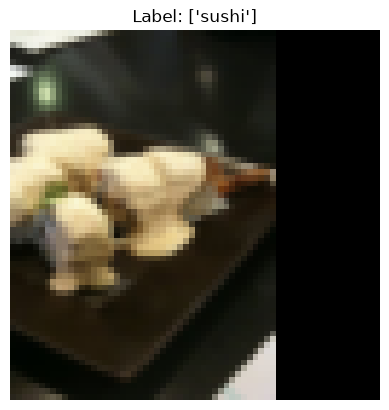

In [282]:
plt.imshow(image.permute(1, 2, 0))
plt.title(f"Label: {[k for k, v in train_data.class_to_idx.items() if v == label]}")
plt.axis("off") 
plt.show()

In [283]:
train_data_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True)
test_data_loader = DataLoader(test_data, batch_size=BATCH_SIZE, shuffle=False)

In [284]:
len(test_data_loader), len(train_data_loader)

(3, 8)

In [285]:
class TinyVGG(nn.Module):
    def __init__(self, input_shape, output_shape, hidden_neurons):
        super().__init__()
        self.conv_block_1 = nn.Sequential(
            nn.Conv2d(in_channels=input_shape, out_channels=hidden_neurons, kernel_size=3, stride=1, padding=0),
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden_neurons, out_channels=hidden_neurons, kernel_size=3, stride=1, padding=0),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )
        self.conv_block_2 = nn.Sequential(
            nn.Conv2d(in_channels=hidden_neurons, out_channels=hidden_neurons, kernel_size=3, stride=1, padding=0),
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden_neurons, out_channels=hidden_neurons, kernel_size=3, stride=1, padding=0),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )

        self.classification_layer = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features=hidden_neurons*169, out_features=output_shape)
        )

    def forward(self, x):
        # print(x.shape)
        x = self.conv_block_1(x)
        # print(x.shape)
        x = self.conv_block_2(x)
        # print(x.shape)
        x = self.classification_layer(x)
        # print(x.shape)
        return x

In [286]:
torch.manual_seed(RANDOM_SEED)
torch.cuda.manual_seed(RANDOM_SEED)
cnn_model = TinyVGG(input_shape=3, output_shape=len(train_data.classes), hidden_neurons=10).to(device=device)

In [287]:
summary(cnn_model, input_size=(BATCH_SIZE, 3, 64,64))

Layer (type:depth-idx)                   Output Shape              Param #
TinyVGG                                  [32, 3]                   --
├─Sequential: 1-1                        [32, 10, 30, 30]          --
│    └─Conv2d: 2-1                       [32, 10, 62, 62]          280
│    └─ReLU: 2-2                         [32, 10, 62, 62]          --
│    └─Conv2d: 2-3                       [32, 10, 60, 60]          910
│    └─ReLU: 2-4                         [32, 10, 60, 60]          --
│    └─MaxPool2d: 2-5                    [32, 10, 30, 30]          --
├─Sequential: 1-2                        [32, 10, 13, 13]          --
│    └─Conv2d: 2-6                       [32, 10, 28, 28]          910
│    └─ReLU: 2-7                         [32, 10, 28, 28]          --
│    └─Conv2d: 2-8                       [32, 10, 26, 26]          910
│    └─ReLU: 2-9                         [32, 10, 26, 26]          --
│    └─MaxPool2d: 2-10                   [32, 10, 13, 13]          --
├─Sequentia

In [288]:
class_names = train_data.classes

In [289]:
optimizer = torch.optim.AdamW(cnn_model.parameters(), lr=.001)
loss_fn = nn.CrossEntropyLoss()
acc_fn = MulticlassAccuracy(num_classes=len(class_names)).to(device)
confmat = ConfusionMatrix(task="multiclass", num_classes=len(class_names))

In [290]:
def train_step(model: torch.nn.Module,
                optimizer: torch.optim.AdamW, 
                loss_fn: torch.nn.CrossEntropyLoss, 
                train_data_loader: torch.utils.data.DataLoader, 
                acc_fn: MulticlassAccuracy, 
                epoch, 
                device: torch.device = device):

    model.train()

    train_loss, train_acc = 0, 0

    pbar = tqdm(train_data_loader, desc=f"training step for the {epoch+1} epoch", leave=False)

    for X, y in pbar:

        X, y = X.to(device), y.to(device)

        optimizer.zero_grad()

        train_logits = model(X)
        train_pred = torch.softmax(train_logits, dim=1).argmax(dim=1)

        train_loss_ = loss_fn(train_logits, y)
        train_loss_.backward()
        train_loss += train_loss_.item()

        optimizer.step()

        train_acc_ = acc_fn(train_pred, y)
        train_acc += train_acc_.item()

    train_acc /= len(train_data_loader)
    train_loss /= len(train_data_loader)

    pbar.set_postfix({"loss": f"{train_loss_.item():.4f}"})

    return train_loss, train_acc

In [291]:
def validation_step(model, 
              loss_fn: torch.nn.CrossEntropyLoss, 
              test_data_loader: torch.utils.data.DataLoader, 
              acc_fn: MulticlassAccuracy, 
              epoch, 
              device: torch.device=device):

    model.eval()
    test_acc, test_loss = 0, 0

    with torch.inference_mode():

        pbar = tqdm(test_data_loader, desc=f"testing step for the {epoch+1} epoch", leave=False)

        for X, y in pbar:

            X, y = X.to(device), y.to(device)
            optimizer.zero_grad()

            test_logits = model(X) 
            test_preds = torch.softmax(test_logits, dim=1).argmax(dim=1)

            test_loss_ = loss_fn(test_logits, y)
            test_loss += test_loss_.item()

            test_acc_ = acc_fn(test_preds, y)
            test_acc += test_acc_.item()

        test_acc /= len(test_data_loader)
        test_loss /= len(test_data_loader)

        pbar.set_postfix({"loss": f"{test_loss_.item():.4f}"})

    return test_loss, test_acc

In [292]:
def train_time(start: float,
               end: float,
               device: torch.device = None):
    total_time = end - start
    print(f"total training time {total_time:.3f} on the {device}")
    return total_time

In [293]:
torch.cuda.manual_seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

start_time = timer()
epochs = 150

test_loss_list = []
train_loss_list = []
train_acc_list = []
test_acc_list = []

epoch_pbar = tqdm(range(epochs), desc="Overall Progress")

for epoch in epoch_pbar:
    train_loss, train_acc = train_step(cnn_model, optimizer, loss_fn, train_data_loader, acc_fn, epoch, device)
    test_loss, test_acc = validation_step(cnn_model, loss_fn, test_data_loader, acc_fn, epoch, device)

    train_loss_list.append(train_loss)
    test_loss_list.append(test_loss)
    train_acc_list.append(train_acc)
    test_acc_list.append(test_acc)

    epoch_pbar.set_postfix({
            "train_loss": f"{train_loss:.4f}",
            "test_acc": f"{test_acc * 100:.2f}%"
        })

end_time = timer()

train_time(start=start_time, end=end_time, device=device)

Overall Progress:   0%|          | 0/150 [00:00<?, ?it/s]

training step for the 1 epoch:   0%|          | 0/8 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:
print(f"the train acc :{train_acc*100}% with a loss of {train_loss}")
print(f"the test acc :{test_acc*100}% with a loss of {test_loss}")

the train acc :71.87378704547882% with a loss of 0.6829499676823616
the test acc :32.8864832719167% with a loss of 0.9683886369069418


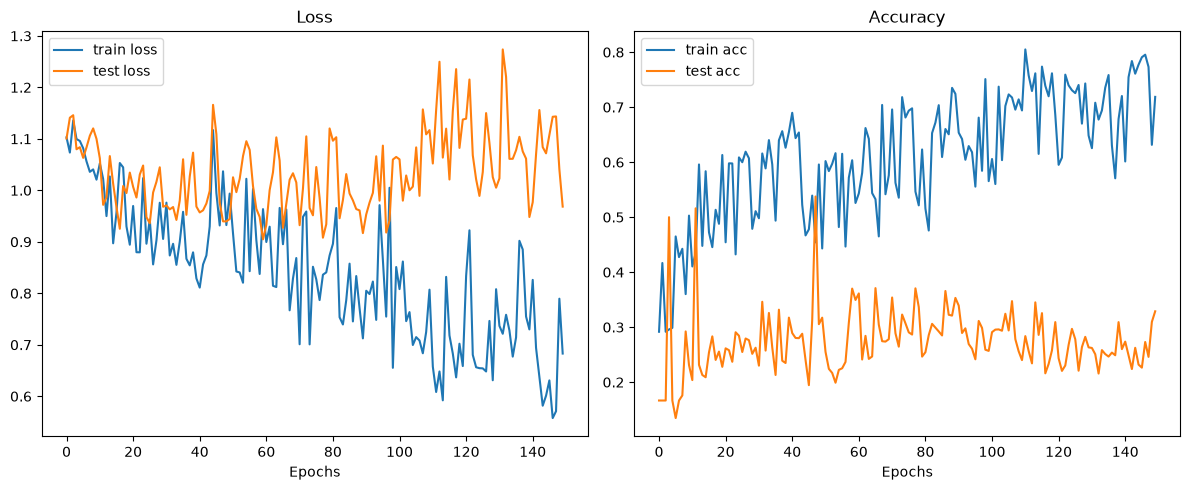

In [ ]:
def loss_acc_plot(test_loss_list=test_loss_list, train_loss_list=train_loss_list, train_acc_list=train_acc_list, test_acc_list=test_acc_list):

    """Plots the accuracy and loss curves for a training model.

    Args:
    -------
        test_loss_list   :    List of test loss values across all training epochs.
        train_loss_list   :   List of train loss values across all training epochs.
        train_acc_list   :   List of train accuracy values across all training epochs.
        test_acc_list   :   List of test accuracy values across all training epochs.
    """
    
    # Extract scalar values from tensors or floats
    train_loss = [l.item() if isinstance(l, torch.Tensor) else l for l in train_loss_list]
    test_loss = [l.item() if isinstance(l, torch.Tensor) else l for l in test_loss_list]
    train_acc = [a.item() if isinstance(a, torch.Tensor) else a for a in train_acc_list]
    test_acc = [a.item() if isinstance(a, torch.Tensor) else a for a in test_acc_list]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

    ax1.plot(train_loss, label="train loss")
    ax1.plot(test_loss, label="test loss")
    ax1.set_title("Loss")
    ax1.set_xlabel("Epochs")
    ax1.legend()

    ax2.plot(train_acc, label="train acc")
    ax2.plot(test_acc, label="test acc")
    ax2.set_title("Accuracy")
    ax2.set_xlabel("Epochs")
    ax2.legend()

    plt.tight_layout()
    plt.show()

loss_acc_plot()

In [ ]:
def eval_model(model: torch.nn.Module, 
              loss_fn: torch.nn.CrossEntropyLoss, 
              test_data_loader: torch.utils.data.DataLoader, 
              acc_fn: MulticlassAccuracy, 
              device: torch.device=device):

    model.eval()
    test_acc, test_loss = 0, 0
    test_preds = []

    with torch.inference_mode():

        pbar = tqdm(test_data_loader, desc=f"model evaluation", leave=False)

        for X, y in pbar:

            X, y = X.to(device), y.to(device)

            test_logits = model(X) 
            test_pred = torch.softmax(test_logits, dim=1).argmax(dim=1)
            test_preds.append(test_pred.cpu())

            test_loss_ = loss_fn(test_logits, y)
            test_loss += test_loss_.item()

            test_acc_ = acc_fn(test_pred, y)
            test_acc += test_acc_.item()

        test_acc /= len(test_data_loader)
        test_loss /= len(test_data_loader)
        test_preds_tensor = torch.cat(test_preds)


        pbar.set_postfix({"loss": f"{test_loss_.item():.4f}"})

    return {
            "model_name": model.__class__.__name__,
            "model_loss": test_loss,
            "model_acc": test_acc
        }, test_preds_tensor

In [ ]:
_ , test_preds_tensor = eval_model(cnn_model, loss_fn, test_data_loader, acc_fn*100, device)
test_preds_tensor[0:10]

model evaluation:   0%|          | 0/3 [00:00<?, ?it/s]

tensor([2, 0, 2, 2, 2, 0, 0, 2, 2, 1])

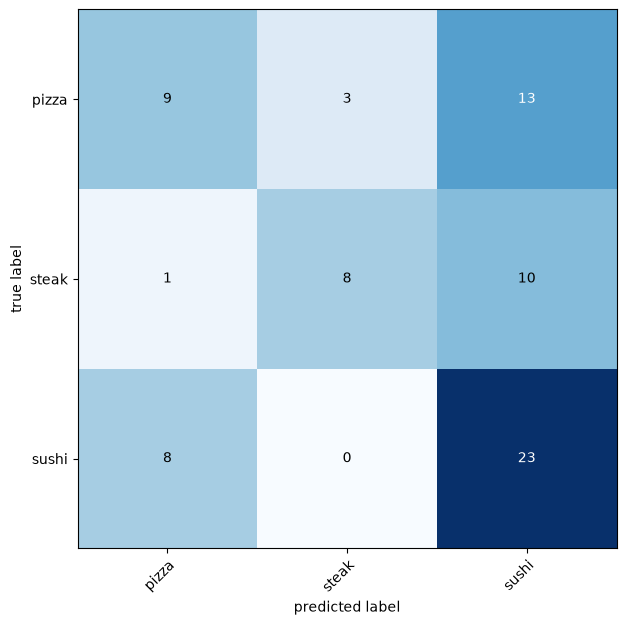

In [ ]:
targets_tensor = torch.tensor(test_data.targets)
confmat_tensor = confmat(test_preds_tensor, targets_tensor)
fig, ax = plot_confusion_matrix(
    conf_mat=confmat_tensor.numpy(), class_names=class_names, figsize=(11, 7)
)
plt.show()

In [329]:
test_image_path = data_path / "test_images" / "04-pizza-dad.jpeg"

if not test_image_path.is_file():
    with open(test_image_path, "wb") as f:
        request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/images/04-pizza-dad.jpeg")
        f.write(request.content)
        print("image downloaded successfully...")

else:
    print("image already exists in file path...")

image already exists in file path...


In [330]:
image = read_image(test_image_path)
image.shape, image.dtype

(torch.Size([3, 4032, 3024]), torch.uint8)

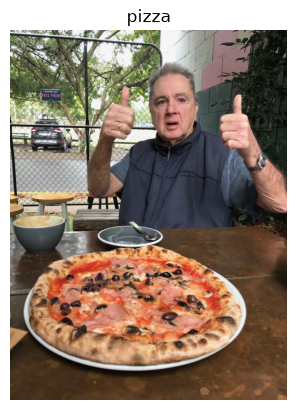

In [331]:
plt.imshow(image.permute(1, 2, 0))
plt.title(f"pizza")
plt.axis("off") 
plt.show()

In [332]:
test_image_transform = v2.Compose([
    v2.Resize(size=(64,64)),
    v2.ToImage(),
])

image_transformed = test_image_transform(image)

In [333]:
image_transformed.shape, image_transformed.dtype

(torch.Size([3, 64, 64]), torch.uint8)

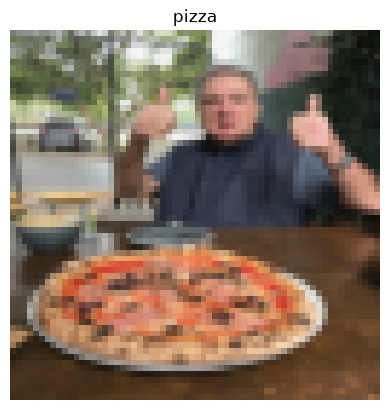

In [334]:
plt.imshow(image_transformed.permute(1, 2, 0))
plt.title(f"pizza")
plt.axis("off") 
plt.show()

In [335]:
final_image = v2.ToDtype(torch.float)(image_transformed)

In [336]:
final_image.shape, final_image.dtype

(torch.Size([3, 64, 64]), torch.float32)

In [337]:
cnn_model.eval()
with torch.inference_mode():
    prediction = cnn_model(final_image.to(device).unsqueeze(dim=0)).argmax(dim=1)

In [338]:
prediction

tensor([2], device='cuda:0')

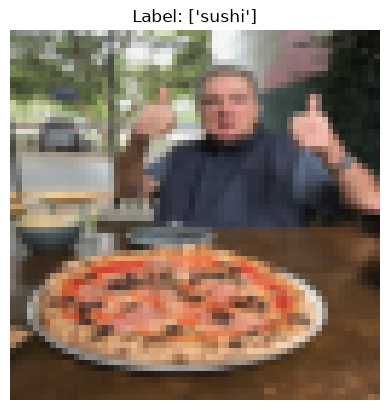

In [339]:
plt.imshow((final_image / 255.0).permute(1, 2, 0))
plt.title(f"Label: {[k for k, v in train_data.class_to_idx.items() if v == prediction]}")
plt.axis("off")
plt.show()